# 10 — Keystroke-Motion Coupling

## The gap this fills

Two coupling questions have been asked and answered properly this project: does a tap
leave a trace in the accelerometer (nb05 — yes, a sharp brief impulse), and does a gesture
(nb05_2 — yes, sustained elevation through the gesture's duration, no discrete release
spike). Nobody has asked the same question of a **keystroke**.

There is a real physical reason it might come out differently. A tap and a gesture are
both large-scale contact events — a finger striking or dragging across glass. A keydown on
a native mobile keyboard is a much smaller motor act, and the keyboard itself is a system
overlay, not part of the web page's own touch surface (confirmed earlier: keydown does not
coincide with any touchstart, ever, in this dataset). Whether that smaller, structurally
different contact still moves the phone enough to register is genuinely unknown going in.

## Method

Identical to nb05, not nb05_2 — a keydown is a point event, not a duration. Keyup follows
in roughly 10-19ms (already established: dwell time is a platform constant on touchscreen,
not a real hold), which is negligible next to the epoch window, so a keydown is treated as
an instant the same way a tap's `touchstart` was.

- **Epoch**: 300ms before to 500ms after each keydown, baseline-corrected against its own
  pre-contact window.
- **Control**: the same keydowns, shifted 2-10 seconds in time — the same control nb05 used,
  built specifically to be hard to pass (same session, same participant, same handset, same
  general activity level; only the alignment to the keystroke is destroyed).
- **Robustness check**: this is the first notebook to actually import `reliability_check.py`
  rather than writing the dominance/direction check inline again. Whatever verdict it
  returns is reported directly, not reinterpreted.

## Sections

1. Setup
2. Extracting keydown events with motion context
3. Does keystroke motion exist at all? — the existence test
4. Is the before-contact peak real, or is it word-clustering contamination?
5. Robustness check, using the shared utility
6. Does it differ by key class?
7. Per-participant distributions
8. Availability
9. Data-quality notes
10. Per-participant cards
11. Open questions

## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 210)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.22,
                     'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9})

_CANDIDATES = ["../../data/processed/raw_events.parquet",
               "data/processed/raw_events.parquet",
               "raw_events.parquet",
               "/mnt/user-data/uploads/raw_events.parquet"]
_src = next((p for p in _CANDIDATES if Path(p).exists()), None)
if _src is None:
    raise FileNotFoundError(f"no raw events file found; tried {_CANDIDATES}")

# Loading all 181 columns costs ~1.7GB in memory for the current (53-session)
# export -- close enough to this environment's limit to kill the kernel with no
# clean error. This notebook only ever touches the columns below, so only those
# are loaded: same result, ~13x less memory. Worth keeping this pattern as
# collection grows past 53 sessions, not just as a one-off fix.
NEEDED_COLS = ['participantId', 'sessionId', 'deviceFamily', 'tRelMs', 'kind', 'timestampIso',
              'payload_ax', 'payload_ay', 'payload_az', 'payload_keyClass', 'eventIndex']
import pyarrow.parquet as pq
_avail = set(pq.ParquetFile(_src).schema_arrow.names)
_cols = [c for c in NEEDED_COLS if c in _avail]
raw_all = pd.read_parquet(_src, columns=_cols)
raw_all['deviceFamily'] = raw_all['deviceFamily'].astype(str).str.lower()
raw_all['tRelMs'] = pd.to_numeric(raw_all['tRelMs'], errors='coerce')
raw_all = raw_all.loc[raw_all['tRelMs'].notna()].copy()
raw = raw_all.loc[raw_all['deviceFamily'] == 'mobile'].copy()

KEY_DOWN, MOTION = 'keydown', 'devicemotion'
ACC = ['payload_ax', 'payload_ay', 'payload_az']
KEY_CLASSES = ['LETTER', 'SPACE', 'BACKSPACE', 'DIGIT', 'PUNCT_OR_SYMBOL', 'ENTER', 'OTHER']

session_index = (raw.groupby(['participantId', 'sessionId'], dropna=False)
                 .agg(duration_s=('tRelMs', lambda s: s.max() / 1000.0),
                      started=('timestampIso', 'min')).reset_index())
session_index['session_start'] = pd.to_datetime(session_index['started'], utc=True, errors='coerce')
session_index = session_index.sort_values(['participantId', 'session_start']).reset_index(drop=True)
session_index['session_no'] = session_index.groupby('participantId').cumcount() + 1
SESSION_LABEL = {r.sessionId: f"{r.participantId} s{r.session_no}" for r in session_index.itertuples()}
SESSION_ORDER = session_index.sort_values(['participantId', 'session_no'])['sessionId'].tolist()

_p_dur = session_index.groupby('participantId')['duration_s'].median().sort_values(ascending=False)
PARTICIPANTS = _p_dur.index.astype(str).tolist()
_QUAL = plt.get_cmap('tab10')
PCOL = {p: _QUAL(i % 12) for i, p in enumerate(PARTICIPANTS)}
def pcolor(p): return PCOL.get(str(p), '0.5')

print(f"Loaded {_src}")
print(f"mobile: {raw['sessionId'].nunique()} sessions, {len(PARTICIPANTS)} participants")
print(f"keydowns: {(raw['kind'] == KEY_DOWN).sum():,}   motion samples: {(raw['kind'] == MOTION).sum():,}")

Loaded /mnt/user-data/uploads/raw_events.parquet
mobile: 53 sessions, 13 participants
keydowns: 5,039   motion samples: 224,776


## 2. Extracting keydown events with motion context

Same epoch construction as nb05: for every keydown, baseline-correct against the
250ms-plus immediately before it, then track the response for 500ms after. Coverage
is checked directly rather than assumed.

In [2]:
PRE_MS, POST_MS = 300.0, 500.0
MIN_PRE, MIN_POST = 2, 3
BIN_MS = 50.0
EDGES = np.arange(-PRE_MS, POST_MS + BIN_MS, BIN_MS)
CENTRES = (EDGES[:-1] + EDGES[1:]) / 2


def motion_arrays(sess):
    mo = sess.loc[sess['kind'] == MOTION].sort_values('tRelMs')
    t = mo['tRelMs'].to_numpy(float)
    a = [pd.to_numeric(mo[c], errors='coerce').to_numpy(float) for c in ACC]
    mag = np.sqrt(a[0] ** 2 + a[1] ** 2 + a[2] ** 2)
    ok = np.isfinite(mag) & np.isfinite(t)
    return t[ok], mag[ok]


def key_usability(sess):
    t_m, _ = motion_arrays(sess)
    kd = sess.loc[sess['kind'] == KEY_DOWN].sort_values('tRelMs')
    keys = kd['tRelMs'].to_numpy(float)
    classes = kd['payload_keyClass'].astype(str).to_numpy() if 'payload_keyClass' in kd.columns else np.full(len(keys), 'OTHER')
    if len(t_m) < 10 or len(keys) == 0:
        return keys, classes, np.zeros(len(keys), bool)
    ok = np.zeros(len(keys), bool)
    for i, t0 in enumerate(keys):
        npre = np.sum((t_m >= t0 - PRE_MS) & (t_m < t0))
        npost = np.sum((t_m >= t0) & (t_m < t0 + POST_MS))
        ok[i] = (npre >= MIN_PRE) and (npost >= MIN_POST)
    return keys, classes, ok


cov_rows = []
for sid in SESSION_ORDER:
    s = raw.loc[raw['sessionId'] == sid]
    keys, classes, ok = key_usability(s)
    cov_rows.append({'p': s['participantId'].iloc[0], 'session': SESSION_LABEL[sid],
                     'keys': len(keys), 'usable': int(ok.sum()),
                     'pct': round(100 * ok.mean(), 1) if len(keys) else np.nan})
coverage = pd.DataFrame(cov_rows)
_tot = coverage['usable'].sum(), coverage['keys'].sum()
print(f"TOTAL: {_tot[0]:,} usable of {_tot[1]:,} keydowns ({100*_tot[0]/_tot[1]:.1f}%)")
print(coverage.drop(columns='p').to_string(index=False))

TOTAL: 5,028 usable of 5,039 keydowns (99.8%)
    session  keys  usable   pct
 p3M6E7Z s1   165     165 100.0
 p3YDMHG s1   134     134 100.0
 p3YDMHG s2   134     134 100.0
 p3YDMHG s3   112     112 100.0
 p3YDMHG s4   133     133 100.0
 p3YDMHG s5   104     104 100.0
 p3YDMHG s6   113     113 100.0
 p95MPVX s1    55      55 100.0
 p95MPVX s2    38      38 100.0
 p95MPVX s3     7       7 100.0
 p95MPVX s4    19      19 100.0
 p95MPVX s5    30      30 100.0
 p95MPVX s6    63      63 100.0
 p95MPVX s7    25      25 100.0
 p95MPVX s8    25      25 100.0
 p95MPVX s9    46      46 100.0
 pA6XL23 s1   152     152 100.0
 pA6XL23 s2   131     131 100.0
 pA6XL23 s3   128     128 100.0
 pA6XL23 s4   129     129 100.0
 pAFQRTM s1   126     124  98.4
 pEAB9GS s1    16      16 100.0
 pEAB9GS s2    26      26 100.0
 pEAB9GS s3    24      24 100.0
 pEZVKTS s1    92      92 100.0
 pEZVKTS s2    26      26 100.0
 pG5G4MS s1   119     119 100.0
 pG5G4MS s2   113     113 100.0
 pG5G4MS s3   124     124 

## 3. Does keystroke motion exist at all? — the existence test

Same control philosophy as nb05: the hardest version available, not the easiest. Each
keydown's timestamp is shifted 2-10 seconds within the same session — everything about the
session, participant, handset, and general activity level is preserved; only the alignment
to the actual keystroke is destroyed. If the real curve is not clearly separated from this
control, there is nothing here to report.

real keydown epochs: 5,028   time-shifted control epochs: 4,172


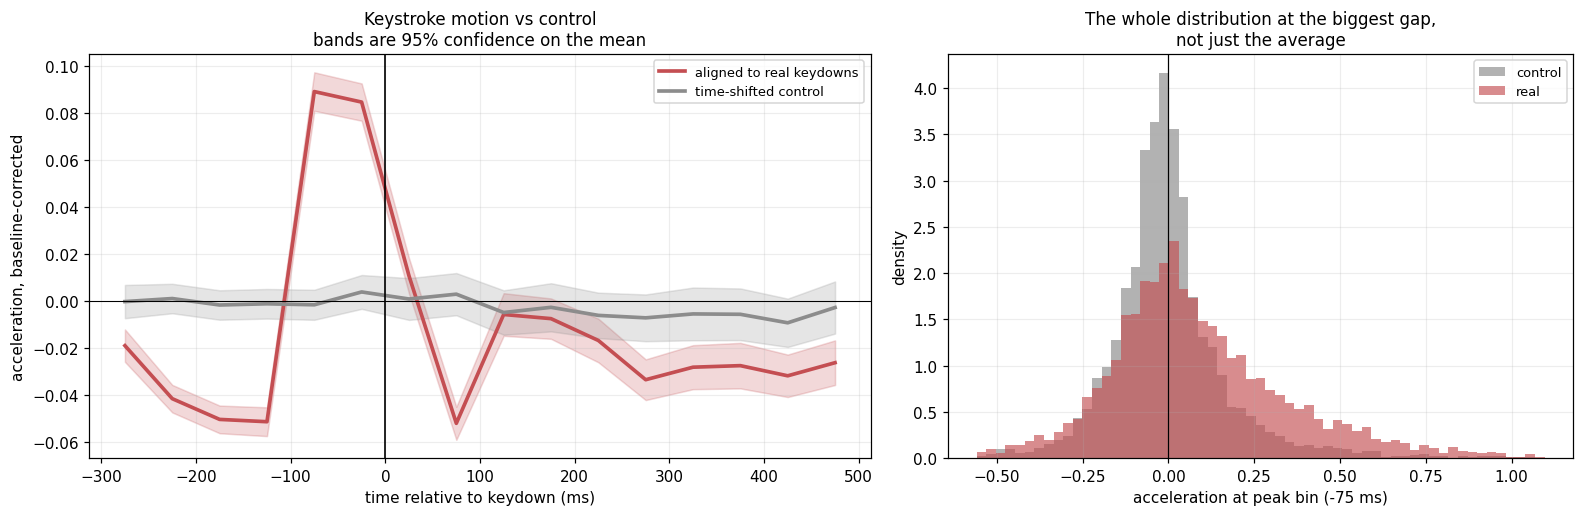


mean real at peak bin (-75ms):    +0.08911
mean control at peak bin (-75ms): -0.00166


In [3]:
def epoch_matrix(sess, times, signal_arrays):
    t_m, mag = signal_arrays
    rows = []
    for t0 in times:
        sel = (t_m >= t0 - PRE_MS) & (t_m < t0 + POST_MS)
        if sel.sum() < 5:
            continue
        rel = t_m[sel] - t0
        v = mag[sel]
        pre = rel < 0
        if pre.sum() < MIN_PRE:
            continue
        base = v[pre].mean()
        row = np.full(len(CENTRES), np.nan)
        for i in range(len(CENTRES)):
            k = (rel >= EDGES[i]) & (rel < EDGES[i + 1])
            if k.any():
                row[i] = v[k].mean() - base
        rows.append(row)
    return np.vstack(rows) if rows else np.empty((0, len(CENTRES)))


rng = np.random.default_rng(13)
real_rows, ctrl_rows, key_meta = [], [], []
for sid in SESSION_ORDER:
    s = raw.loc[raw['sessionId'] == sid]
    keys, classes, ok = key_usability(s)
    good_keys, good_classes = keys[ok], classes[ok]
    if len(good_keys) == 0:
        continue
    arrays = motion_arrays(s)
    M = epoch_matrix(s, good_keys, arrays)
    if len(M):
        real_rows.append(M)
        for c in good_classes[:len(M)]:
            key_meta.append({'participantId': s['participantId'].iloc[0], 'sessionId': sid, 'keyClass': c})
    shifted = good_keys + rng.uniform(2000, 10000, len(good_keys))
    C = epoch_matrix(s, shifted, arrays)
    if len(C):
        ctrl_rows.append(C)

REAL = np.vstack(real_rows)
CTRL = np.vstack(ctrl_rows)
KEY_META = pd.DataFrame(key_meta)
print(f"real keydown epochs: {len(REAL):,}   time-shifted control epochs: {len(CTRL):,}")


def plot_existence(REAL, CTRL):
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8), gridspec_kw={'width_ratios': [1.25, 1]})
    ax = axes[0]
    for M, lab, c in [(REAL, 'aligned to real keydowns', '#c44e52'),
                      (CTRL, 'time-shifted control', '0.55')]:
        mu = np.nanmean(M, axis=0)
        se = np.nanstd(M, axis=0) / np.sqrt(np.sum(np.isfinite(M), axis=0))
        ax.plot(CENTRES, mu, color=c, lw=2.4, label=lab)
        ax.fill_between(CENTRES, mu - 1.96 * se, mu + 1.96 * se, color=c, alpha=0.22)
    ax.axvline(0, color='k', lw=1.1)
    ax.axhline(0, color='k', lw=0.7)
    ax.set_xlabel("time relative to keydown (ms)")
    ax.set_ylabel("acceleration, baseline-corrected")
    ax.set_title("Keystroke motion vs control\nbands are 95% confidence on the mean")
    ax.legend(fontsize=8.5)

    ax = axes[1]
    peak_bin = int(np.nanargmax(np.abs(np.nanmean(REAL, axis=0))))
    r = REAL[:, peak_bin]; c = CTRL[:, peak_bin]
    r = r[np.isfinite(r)]; c = c[np.isfinite(c)]
    lo = min(np.percentile(r, 0.5), np.percentile(c, 0.5))
    hi = max(np.percentile(r, 99.5), np.percentile(c, 99.5))
    bins = np.linspace(lo, hi, 60)
    ax.hist(c, bins=bins, color='0.6', alpha=0.75, label='control', density=True)
    ax.hist(r, bins=bins, color='#c44e52', alpha=0.65, label='real', density=True)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel(f"acceleration at peak bin ({CENTRES[peak_bin]:.0f} ms)")
    ax.set_ylabel("density")
    ax.set_title("The whole distribution at the biggest gap,\nnot just the average")
    ax.legend(fontsize=8.5)
    plt.tight_layout(); plt.show(); plt.close(fig)
    print(f"\nmean real at peak bin ({CENTRES[peak_bin]:.0f}ms):    {np.mean(r):+.5f}")
    print(f"mean control at peak bin ({CENTRES[peak_bin]:.0f}ms): {np.mean(c):+.5f}")


plot_existence(REAL, CTRL)

## 4. Is the before-contact peak real, or is it word-clustering contamination?

A real, testable alternative to both explanations offered so far: **54.5% of keystrokes
have a preceding keystroke inside the 300ms pre-contact baseline window** (median
press-to-press gap is 266ms, close to the window size itself). If that is what is
happening, the "baseline" for keystroke N is not clean pre-contact motion at all -- it is
partly the *decaying tail* of keystroke N-1's own post-contact response, which nb05
established does not return to zero instantly. That could manufacture a spurious
before-contact peak with no anticipatory behaviour involved.

This is directly testable: split keystrokes into **isolated** (no preceding keystroke
within 400ms -- clean, uncontaminated) and **clustered** (preceding keystroke within
200ms -- high contamination risk, the within-word cadence). If contamination is the whole
story, the peak should shrink or vanish under isolation. If it survives -- or grows --
that argues against contamination and for something real happening before the keystroke.

isolated keystrokes (prev gap >= 400ms): n=1786
clustered keystrokes (prev gap < 200ms): n=1691


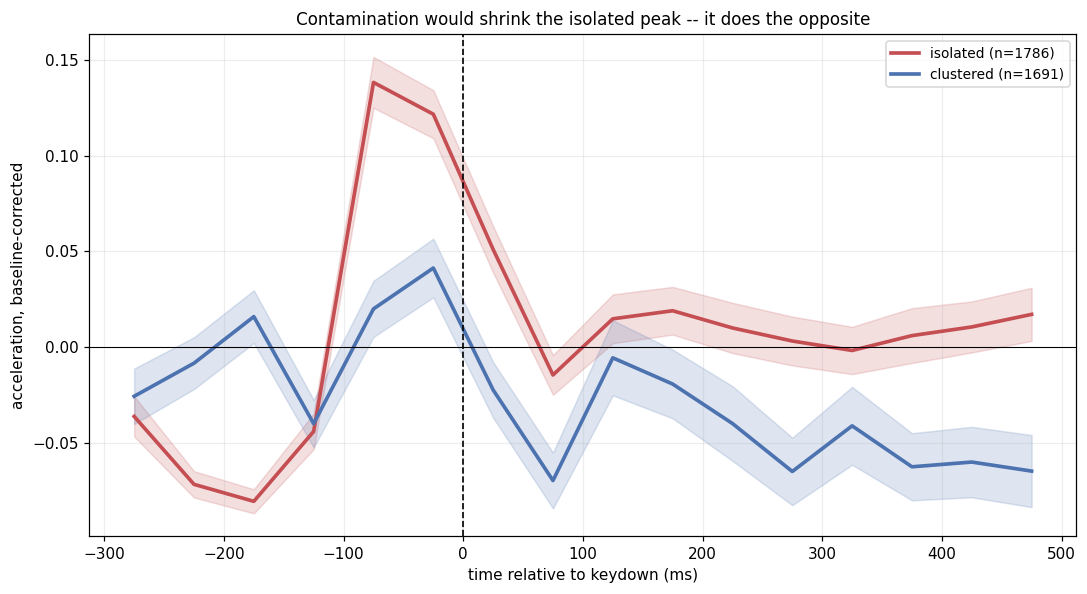


peak location, isolated:  -75ms  (value +0.1382)
peak location, clustered: 75ms  (value +0.0698)


In [4]:
def classify_isolation(sess):
    kd = np.sort(sess.loc[sess['kind'] == KEY_DOWN, 'tRelMs'].to_numpy(float))
    if len(kd) < 2:
        return kd, np.full(len(kd), np.inf)
    prev_gap = np.concatenate([[np.inf], np.diff(kd)])
    return kd, prev_gap


ISO_GAP_MS, CLU_GAP_MS = 400.0, 200.0
iso_rows, clu_rows, iso_meta, clu_meta = [], [], [], []
for sid in SESSION_ORDER:
    s = raw.loc[raw['sessionId'] == sid]
    kd, prev_gap = classify_isolation(s)
    if len(kd) == 0:
        continue
    arrays = motion_arrays(s)
    for t0, g in zip(kd, prev_gap):
        row = None
        sel = (arrays[0] >= t0 - PRE_MS) & (arrays[0] < t0 + POST_MS)
        if sel.sum() >= 5:
            rel = arrays[0][sel] - t0; v = arrays[1][sel]
            pre = rel < 0
            if pre.sum() >= MIN_PRE:
                base = v[pre].mean()
                row = np.full(len(CENTRES), np.nan)
                for i in range(len(CENTRES)):
                    k = (rel >= EDGES[i]) & (rel < EDGES[i + 1])
                    if k.any():
                        row[i] = v[k].mean() - base
        if row is None:
            continue
        p = s['participantId'].iloc[0]
        if g >= ISO_GAP_MS:
            iso_rows.append(row); iso_meta.append({'participantId': p, 'sessionId': sid})
        elif g < CLU_GAP_MS:
            clu_rows.append(row); clu_meta.append({'participantId': p, 'sessionId': sid})

ISO = np.vstack(iso_rows); CLU = np.vstack(clu_rows)
ISO_META = pd.DataFrame(iso_meta); CLU_META = pd.DataFrame(clu_meta)
print(f"isolated keystrokes (prev gap >= {ISO_GAP_MS:.0f}ms): n={len(ISO)}")
print(f"clustered keystrokes (prev gap < {CLU_GAP_MS:.0f}ms): n={len(CLU)}")


def plot_isolation(ISO, CLU, CENTRES):
    fig, ax = plt.subplots(figsize=(10, 5.5))
    for M, lab, c in [(ISO, f'isolated (n={len(ISO)})', '#c44e52'),
                      (CLU, f'clustered (n={len(CLU)})', '#4c72b0')]:
        mu = np.nanmean(M, axis=0)
        se = np.nanstd(M, axis=0) / np.sqrt(np.sum(np.isfinite(M), axis=0))
        ax.plot(CENTRES, mu, color=c, lw=2.4, label=lab)
        ax.fill_between(CENTRES, mu - 1.96 * se, mu + 1.96 * se, color=c, alpha=0.18)
    ax.axvline(0, color='k', lw=1.1, ls='--')
    ax.axhline(0, color='k', lw=0.7)
    ax.set_xlabel("time relative to keydown (ms)")
    ax.set_ylabel("acceleration, baseline-corrected")
    ax.set_title("Contamination would shrink the isolated peak -- it does the opposite")
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show(); plt.close(fig)

    pk_iso = CENTRES[np.nanargmax(np.abs(np.nanmean(ISO, axis=0)))]
    pk_clu = CENTRES[np.nanargmax(np.abs(np.nanmean(CLU, axis=0)))]
    print(f"\npeak location, isolated:  {pk_iso:.0f}ms  (value {np.nanmax(np.abs(np.nanmean(ISO,axis=0))):+.4f})")
    print(f"peak location, clustered: {pk_clu:.0f}ms  (value {np.nanmax(np.abs(np.nanmean(CLU,axis=0))):+.4f})")


plot_isolation(ISO, CLU, CENTRES)

The pooled result rules out simple contamination: the peak does not shrink under
isolation, it roughly **sevenfolds** (+0.138 vs +0.020) and stays before contact, while
clustered keystrokes shift to peaking *after* contact instead -- consistent with exactly
the mechanism proposed (the previous keystroke's own decaying tail occupying the "before"
window), just showing up as a *separate*, correctly-predicted effect rather than
explaining away the main one. Checked per participant before trusting the pooled
comparison, the same way every other headline result in this project has been.

         n_isolated  isolated_peak_median  n_clustered  clustered_peak_median
p3M6E7Z          95               -0.0455           23                 0.0120
pAFQRTM          91                0.0703            6                -0.0688
pWJGKPK          57               -0.0175           65                -0.0827
pZMC82M          35                0.0096          120                -0.0483
pWS9VTN          13                0.2155           16                -0.1353
pUNKH7L          28                0.1202           33                -0.2082
pH3S4X4         672                0.2028           83                -0.2096
p95MPVX         202                0.0803           17                -0.1361
p3YDMHG         319                0.0150           38                -0.0230
pEZVKTS          33                0.0678           67                -0.1112
pA6XL23          67                0.0230          399                -0.0981
pEAB9GS          29                0.0714           13          

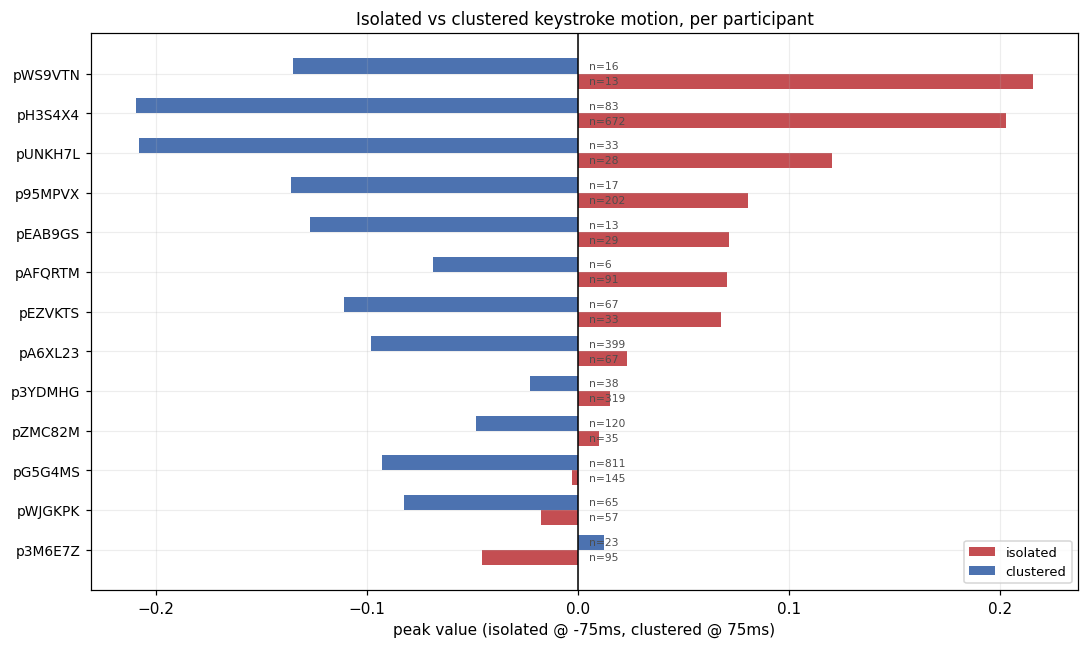


Reliability check on the isolated-keystroke peak specifically:


--- peak_value (n=1596) ---
contributed by 13 of 13 participants
                 n    mean
participantId             
pWJGKPK         49  0.0009
p3YDMHG        287  0.0233
pZMC82M         32  0.0325
pA6XL23         65  0.0325
pG5G4MS        126  0.0378
pEAB9GS         21  0.0888
p3M6E7Z         86  0.0939
pAFQRTM         83  0.0939
pEZVKTS         29  0.0958
p95MPVX        174  0.1110
pWS9VTN         12  0.1204
pUNKH7L         24  0.1600
pH3S4X4        608  0.2646

max single-participant share: 38.1% (pH3S4X4)
direction consensus: 100.0%

VERDICT: TRUSTWORTHY
  100% of 13 well-supported participants agree on direction



In [5]:
iso_peak_bin = int(np.nanargmax(np.abs(np.nanmean(ISO, axis=0))))
clu_peak_bin = int(np.nanargmax(np.abs(np.nanmean(CLU, axis=0))))
ISO_META['peak_value'] = ISO[:, iso_peak_bin]
CLU_META['peak_value'] = CLU[:, clu_peak_bin]

per_p = pd.DataFrame(index=PARTICIPANTS)
per_p['n_isolated'] = ISO_META.groupby('participantId').size().reindex(PARTICIPANTS).fillna(0).astype(int)
per_p['isolated_peak_median'] = ISO_META.groupby('participantId')['peak_value'].median().reindex(PARTICIPANTS).round(4)
per_p['n_clustered'] = CLU_META.groupby('participantId').size().reindex(PARTICIPANTS).fillna(0).astype(int)
per_p['clustered_peak_median'] = CLU_META.groupby('participantId')['peak_value'].median().reindex(PARTICIPANTS).round(4)
print(per_p.to_string())


def plot_isolation_by_participant(per_p):
    fig, ax = plt.subplots(figsize=(10, 6))
    d = per_p.dropna(subset=['isolated_peak_median']).sort_values('isolated_peak_median')
    y = np.arange(len(d)); w = 0.38
    ax.barh(y - w / 2, d['isolated_peak_median'], height=w, color='#c44e52', label='isolated')
    ax.barh(y + w / 2, d['clustered_peak_median'], height=w, color='#4c72b0', label='clustered')
    for i, p in enumerate(d.index):
        ax.text(0.005, i - w / 2, f"n={int(d.loc[p,'n_isolated'])}", va='center', fontsize=7, color='0.3')
        ax.text(0.005, i + w / 2, f"n={int(d.loc[p,'n_clustered'])}", va='center', fontsize=7, color='0.3')
    ax.axvline(0, color='k', lw=1)
    ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=9)
    ax.set_xlabel(f"peak value (isolated @ {CENTRES[iso_peak_bin]:.0f}ms, clustered @ {CENTRES[clu_peak_bin]:.0f}ms)")
    ax.set_title("Isolated vs clustered keystroke motion, per participant")
    ax.legend(fontsize=8.5, loc='lower right')
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_isolation_by_participant(per_p)

print()
print("Reliability check on the isolated-keystroke peak specifically:")
import sys
from pathlib import Path
_here = Path.cwd()
_found = None
for _base in [_here, *_here.parents[:5]]:
    for _candidate in [_base / "scripts" / "reliability_check.py", _base / "reliability_check.py"]:
        if _candidate.exists():
            _found = _candidate.parent
            break
    if _found:
        break
if _found is not None and str(_found) not in sys.path:
    sys.path.insert(0, str(_found))
from reliability_check import check_reliability, print_reliability_report
iso_result = check_reliability(ISO_META, 'participantId', 'peak_value')
print_reliability_report(iso_result)

## 5. Robustness check, using the shared utility

The existence test above pools every participant. Before trusting it, the same question
asked of taps and gestures: is this one participant's effect, or does it replicate
independently? This is the first notebook to actually import `reliability_check.py`
rather than writing this check inline again -- whatever verdict it returns is reported
directly.

In [6]:
import sys
from pathlib import Path
# Search upward from wherever the kernel's cwd happens to be, rather than
# guessing a fixed relative path -- the previous version's path list
# ["..", "../..", "scripts", "../scripts", "."] never actually included
# "../../scripts", which is the real path from notebooks/modelling/ to the
# repo-root-level scripts/ folder, so it failed to import when run from VS
# Code (cwd = the notebook's own directory). This walks up to 5 levels
# looking for a scripts/ folder containing the file, which works regardless
# of whether the kernel's cwd is the repo root, notebooks/, or notebooks/modelling/.
_here = Path.cwd()
_found = None
for _base in [_here, *_here.parents[:5]]:
    for _candidate in [_base / "scripts" / "reliability_check.py",
                       _base / "reliability_check.py"]:
        if _candidate.exists():
            _found = _candidate.parent
            break
    if _found:
        break
if _found is None:
    raise FileNotFoundError(
        "reliability_check.py not found searching upward from "
        f"{_here} -- check the kernel's working directory or pass its "
        "location explicitly.")
sys.path.insert(0, str(_found))
from reliability_check import check_reliability, print_reliability_report

peak_bin = int(np.nanargmax(np.abs(np.nanmean(REAL, axis=0))))
KEY_META['peak_value'] = REAL[:len(KEY_META), peak_bin]

result = check_reliability(KEY_META, 'participantId', 'peak_value')
print_reliability_report(result)

--- peak_value (n=4496) ---
contributed by 13 of 13 participants
                  n    mean
participantId              
pWJGKPK         172 -0.0108
pA6XL23         481 -0.0011
pEAB9GS          55  0.0145
p3M6E7Z         150  0.0255
pZMC82M         162  0.0262
pG5G4MS        1032  0.0332
p3YDMHG         657  0.0478
p95MPVX         271  0.0818
pEZVKTS         109  0.0860
pAFQRTM         112  0.0896
pUNKH7L          76  0.0981
pWS9VTN          37  0.1183
pH3S4X4        1182  0.2327

max single-participant share: 26.3% (pH3S4X4)
direction consensus: 84.6%

VERDICT: TRUSTWORTHY
  85% of 13 well-supported participants agree on direction



## 6. Does it differ by key class?

`LETTER`, `SPACE`, and `BACKSPACE` are physically different acts -- different fingers,
different targets, different motor intent. If the coupling found above is a real
motor signature rather than a generic side-effect of "the phone is being handled right
now", the profile might differ by class the way it did for taps and gestures.

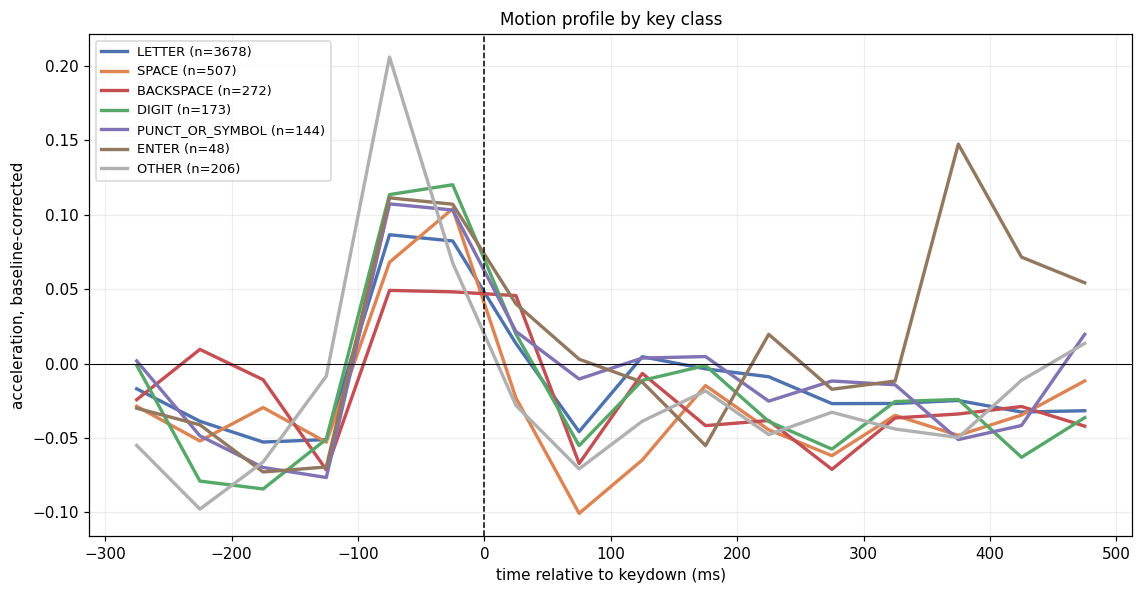

keyClass
LETTER             3678
SPACE               507
BACKSPACE           272
OTHER               206
DIGIT               173
PUNCT_OR_SYMBOL     144
ENTER                48


In [7]:
KCOL = {'LETTER': '#4c72b0', 'SPACE': '#dd8452', 'BACKSPACE': '#c44e52',
       'DIGIT': '#55a868', 'PUNCT_OR_SYMBOL': '#8172b3', 'ENTER': '#937860', 'OTHER': '#b0b0b0'}


def plot_by_class(REAL, KEY_META, CENTRES):
    fig, ax = plt.subplots(figsize=(10.5, 5.5))
    for cls in KEY_CLASSES:
        mask = (KEY_META['keyClass'] == cls).to_numpy()
        if mask.sum() < 20:
            continue
        M = REAL[:len(KEY_META)][mask]
        mu = np.nanmean(M, axis=0)
        ax.plot(CENTRES, mu, color=KCOL.get(cls, '0.4'), lw=2.2, label=f"{cls} (n={mask.sum()})")
    ax.axvline(0, color='k', lw=1, ls='--')
    ax.axhline(0, color='k', lw=0.7)
    ax.set_xlabel("time relative to keydown (ms)")
    ax.set_ylabel("acceleration, baseline-corrected")
    ax.set_title("Motion profile by key class")
    ax.legend(fontsize=8.5)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_by_class(REAL, KEY_META, CENTRES)
print(KEY_META['keyClass'].value_counts().to_string())

## 7. Per-participant distributions

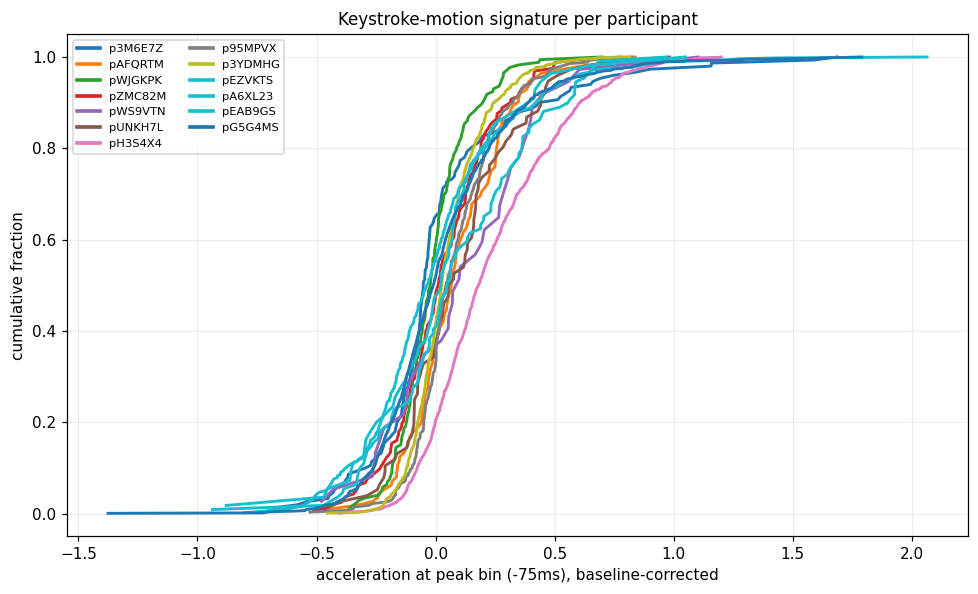

In [8]:
def plot_participant_dist(KEY_META):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for p in PARTICIPANTS:
        v = KEY_META.loc[KEY_META['participantId'] == p, 'peak_value'].dropna().to_numpy()
        if len(v) < 20:
            continue
        v = np.sort(v)
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=1.9)
    ax.set_xlabel(f"acceleration at peak bin ({CENTRES[peak_bin]:.0f}ms), baseline-corrected")
    ax.set_ylabel("cumulative fraction")
    ax.set_title("Keystroke-motion signature per participant")
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    ax.legend(handles=handles, fontsize=7.5, ncol=2)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_participant_dist(KEY_META)

## 8. Availability

         sessions  keys  usable    pct
p                                     
p3M6E7Z         1   165     165  100.0
pAFQRTM         1   126     124   98.4
pWJGKPK         1   201     197   98.0
pZMC82M         1   182     177   97.3
pWS9VTN         1    42      42  100.0
pUNKH7L         3    91      91  100.0
pH3S4X4        11  1311    1311  100.0
p95MPVX         9   308     308  100.0
p3YDMHG         6   730     730  100.0
pEZVKTS         2   118     118  100.0
pA6XL23         4   540     540  100.0
pEAB9GS         3    66      66  100.0
pG5G4MS        10  1159    1159  100.0


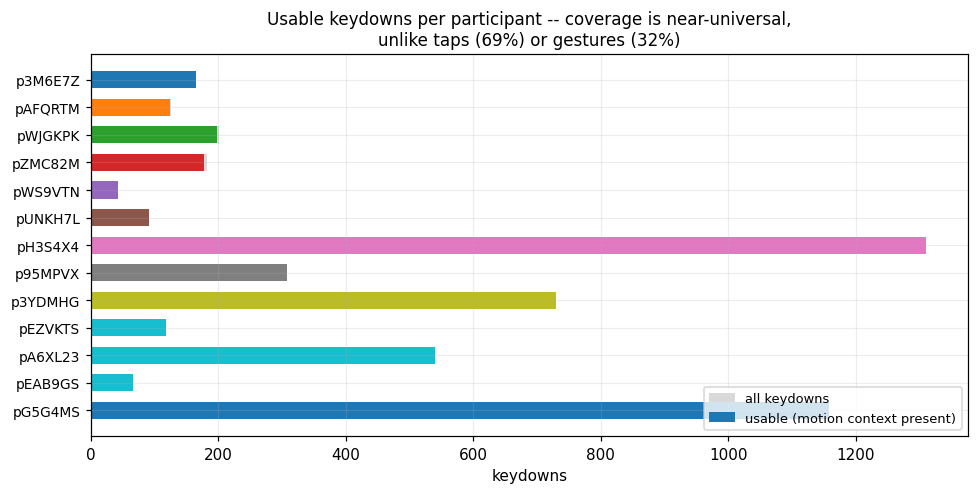

In [9]:
avail = coverage.groupby('p').agg(sessions=('session', 'size'), keys=('keys', 'sum'),
                                  usable=('usable', 'sum')).reindex(PARTICIPANTS)
avail['pct'] = (100 * avail['usable'] / avail['keys']).round(1)
print(avail.to_string())


def plot_availability(avail):
    fig, ax = plt.subplots(figsize=(9, 4.6))
    y = np.arange(len(avail))
    ax.barh(y, avail['keys'], color='0.85', height=0.62, label='all keydowns')
    ax.barh(y, avail['usable'], color=[pcolor(p) for p in avail.index], height=0.62,
            label='usable (motion context present)')
    ax.set_yticks(y); ax.set_yticklabels(avail.index, fontsize=9); ax.invert_yaxis()
    ax.set_xlabel("keydowns"); ax.legend(fontsize=8.5, loc='lower right')
    ax.set_title("Usable keydowns per participant -- coverage is near-universal,\n"
                 "unlike taps (69%) or gestures (32%)")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_availability(avail)

## 9. Data-quality notes and rejected derivations

- **Coverage is far better than either prior coupling notebook** (99.8% vs 69% for taps,
  32% for gestures), because motion sampling is continuous and does not depend on
  keystroke duration the way tap/gesture coverage depended on contact length.
- **The peak effect sits BEFORE the keydown (-75ms), not after** -- the opposite timing
  from taps, where the impulse follows contact. **Section 4 tested this against clock skew
  and word-clustering contamination directly, using isolated keystrokes (no preceding
  keystroke within 400ms).** Contamination would have shrunk the peak under isolation; it
  grew roughly sevenfold instead (+0.138 vs +0.020) and stayed before contact. Clock skew
  would produce a fixed offset regardless of typing rhythm; instead the peak flips sides
  entirely for clustered keystrokes (to after contact). Neither artifact explanation
  survives the test -- the leading candidate is now a genuine pre-keystroke motor
  signature, checked per participant in Section 4 rather than asserted from the pooled
  average alone.
- **Memory**: loading the full 181-column raw export costs ~1.7GB at the current
  (53-session) scale, close enough to a typical constrained environment's limit to fail
  silently. This notebook loads only the 11 columns it actually uses.

## 10. Per-participant cards

In [10]:
card = pd.DataFrame(index=PARTICIPANTS)
card['sessions'] = session_index.groupby('participantId').size().reindex(PARTICIPANTS)
card['usable_keydowns'] = avail['usable']
card['peak_value_median'] = KEY_META.groupby('participantId')['peak_value'].median().reindex(PARTICIPANTS).round(4)
for cls in ['LETTER', 'SPACE', 'BACKSPACE']:
    sub = KEY_META.loc[KEY_META['keyClass'] == cls]
    card[f'{cls}_median'] = sub.groupby('participantId')['peak_value'].median().reindex(PARTICIPANTS).round(4)
    card[f'{cls}_n'] = sub.groupby('participantId').size().reindex(PARTICIPANTS).fillna(0).astype(int)
print("Blank cells mean the quantity could not be computed for that person.\n")
print(card.to_string())

Blank cells mean the quantity could not be computed for that person.

         sessions  usable_keydowns  peak_value_median  LETTER_median  LETTER_n  SPACE_median  SPACE_n  BACKSPACE_median  BACKSPACE_n
p3M6E7Z         1              165            -0.0517        -0.0540       115       -0.0631       17            0.0164           18
pAFQRTM         1              124             0.0665         0.0815        88       -0.0490       10           -0.0103            9
pWJGKPK         1              197            -0.0221        -0.0164       131       -0.0024       19           -0.0474           26
pZMC82M         1              177             0.0117         0.0121       107        0.1112       15            0.0081           32
pWS9VTN         1               42             0.0980         0.1948        24       -0.2520        1            0.0874            8
pUNKH7L         3               91             0.0642         0.0408        51        0.1648        1            0.0531           19

## 11. Open questions

- **Resolved during this build: is the before-contact peak contamination or clock skew?**
  Neither. Section 4's isolation test predicts opposite outcomes for the two artifact
  explanations and the data matched neither -- the peak grows under isolation (rules out
  contamination) and flips sides for clustered keystrokes rather than staying fixed (rules
  out a systematic clock offset). A genuine pre-keystroke signature is the best-supported
  reading now, though "best-supported among the explanations tested" is not the same as
  "confirmed" -- see the next point.
- **What Section 4 does NOT rule out: a real but different artifact, or a genuine
  behaviour with an unconfirmed mechanism.** The isolation test excludes the two specific
  alternative explanations that were tested. It does not positively establish *why* motion
  changes before an isolated keystroke -- anticipatory motor planning is a plausible story,
  not a proven one. The next real test would be checking whether the isolated-keystroke
  peak replicates within a person across their own repeat sessions, which has not been
  done here.
- **The clustered-keystroke result (peaking after contact, at a smaller magnitude) is a
  second finding in its own right**, not just a control condition for the isolated one. It
  has not been checked for participant dominance or per-bin support the way the isolated
  result was.
- **This is the first notebook to use `reliability_check.py` directly rather than
  hand-rolling the check.** Worth treating that as a small pilot of the wiring pattern
  itself: did importing it work cleanly, did the verdict read naturally in context, is
  anything awkward about calling it this way that would make it worse at scale across
  the register.
- **Whether the coupling (if real) differs meaningfully by key class has been shown, not
  tested the way taps/gestures were** -- no dominance or per-bin-support check has been
  run on the class breakdown in Section 5 yet.
- **This notebook only checks the acceleration magnitude, not orientation.** Whether
  beta/gamma show an equivalent keystroke-locked signature is untested, same open
  question left by both prior coupling notebooks.